# 🏗️ Retail Store Inventory Forecasting — Baseline Models

**Objective:** Train and evaluate three baseline regression models to predict **Units Sold**, establishing performance benchmarks for future model refinement.

**Why Baselines Matter?**  
Before investing time in complex architectures or exhaustive hyperparameter tuning, we need to understand how well simple, out-of-the-box models perform. This gives us:
- A **performance floor** — any tuned model should beat these numbers.
- **Relative comparison** — which model family best captures the structure of this data?
- **Diagnostic insight** — large gaps between models hint at non-linearities or feature interactions.

### Models
| # | Model | Type | Key Characteristics |
|---|-------|------|---------------------|
| 1 | **Linear Regression** | Linear | Simple, interpretable, assumes linear feature–target relationship |
| 2 | **Random Forest Regressor** | Ensemble (Bagging) | Handles non-linearity, robust to outliers, implicit feature selection |
| 3 | **XGBoost Regressor** | Ensemble (Boosting) | Sequential error correction, often state-of-the-art on tabular data |

### Evaluation Metrics
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | Mean Absolute Error | Average magnitude of errors (same units as target) |
| **RMSE** | Root Mean Squared Error | Penalises large errors more heavily than MAE |
| **R²** | Coefficient of Determination | Proportion of variance explained (1.0 = perfect) |

---

**This notebook covers:**
1. Import Libraries & Load Data
2. Define Features & Target
3. Train–Test Split
4. Feature Scaling
5. Model 1 — Linear Regression
6. Model 2 — Random Forest Regressor
7. Model 3 — XGBoost Regressor
8. Comparative Results & Visualisation
9. Residual Analysis
10. Conclusions & Next Steps

---
## 1. Import Libraries & Load Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Load the feature-engineered dataset
df = pd.read_csv('advanced_feature_engineered_retail_inventory.csv')
print(f'✅ Dataset loaded successfully.')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Target variable: Units Sold')
print(f'\nColumns: {list(df.columns)}')
df.head()

✅ Dataset loaded successfully.
   Shape: 73,100 rows × 40 columns
   Target variable: Units Sold

Columns: ['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend', 'PRICE_DIFF', 'PRICE_RATIO', 'DISCOUNTED_PRICE', 'INVENTORY_COVERAGE', 'STOCK_GAP', 'PROMO_DISCOUNT', 'HIGH_DISCOUNT_FLAG', 'COMPETITOR_CHEAPER', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'INVENTORY_UTILIZATION', 'PRICE_COMPETITIVENESS', 'PROMOTION_STRENGTH', 'PRICE_PER_INVENTORY', 'DISCOUNT_PRICE_RATIO', 'INVENTORY_VALUE', 'COMPETITOR_PRICE_DIFF_PERCENT', 'CATEGORY_SEASON_ENC', 'CATEGORY_WEATHER_ENC']


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,DOW_COS,INVENTORY_UTILIZATION,PRICE_COMPETITIVENESS,PROMOTION_STRENGTH,PRICE_PER_INVENTORY,DISCOUNT_PRICE_RATIO,INVENTORY_VALUE,COMPETITOR_PRICE_DIFF_PERCENT,CATEGORY_SEASON_ENC,CATEGORY_WEATHER_ENC
0,0,0,3,1,231,127,55,33.50,20,1,...,-0.222521,0.237069,1.091561,0,0.144397,0.579710,7738.50,12.414467,12,13
1,0,1,4,2,204,150,66,63.01,20,3,...,-0.222521,0.321951,0.938207,0,0.307366,0.312451,12854.04,-4.690292,16,19
2,0,2,4,3,102,65,51,27.99,10,3,...,-0.222521,0.495146,0.866027,10,0.271748,0.344947,2854.98,-10.303218,18,19
3,0,3,4,1,469,61,164,32.72,10,0,...,-0.222521,0.348936,0.915501,10,0.069617,0.296560,15345.68,-5.651931,16,16
4,0,4,1,0,166,14,135,73.64,0,3,...,-0.222521,0.808383,1.052752,0,0.440958,0.000000,12224.24,6.704789,6,7


---
## 2. Define Features & Target

We separate the dataset into:
- **X (features):** All columns except `Units Sold`
- **y (target):** `Units Sold`

In [20]:
# Define target and features
TARGET = 'Units Sold'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features (X): {X.shape[1]} columns')
print(f'Target   (y): {y.name}\n')
print(f'Feature list:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\n--- Target Distribution ---')
print(y.describe().round(2))

Features (X): 39 columns
Target   (y): Units Sold

Feature list:
   1. Store ID
   2. Product ID
   3. Category
   4. Region
   5. Inventory Level
   6. Units Ordered
   7. Price
   8. Discount
   9. Weather Condition
  10. Holiday/Promotion
  11. Competitor Pricing
  12. Seasonality
  13. Year
  14. Month
  15. Day
  16. DayOfWeek
  17. Quarter
  18. IsWeekend
  19. PRICE_DIFF
  20. PRICE_RATIO
  21. DISCOUNTED_PRICE
  22. INVENTORY_COVERAGE
  23. STOCK_GAP
  24. PROMO_DISCOUNT
  25. HIGH_DISCOUNT_FLAG
  26. COMPETITOR_CHEAPER
  27. MONTH_SIN
  28. MONTH_COS
  29. DOW_SIN
  30. DOW_COS
  31. INVENTORY_UTILIZATION
  32. PRICE_COMPETITIVENESS
  33. PROMOTION_STRENGTH
  34. PRICE_PER_INVENTORY
  35. DISCOUNT_PRICE_RATIO
  36. INVENTORY_VALUE
  37. COMPETITOR_PRICE_DIFF_PERCENT
  38. CATEGORY_SEASON_ENC
  39. CATEGORY_WEATHER_ENC

--- Target Distribution ---
count    73100.00
mean       136.46
std        108.92
min          0.00
25%         49.00
50%        107.00
75%        203.00
max   

---
## 3. Train–Test Split

We use an **80/20 split** with a fixed `random_state` for reproducibility.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'\nFeature count: {X_train.shape[1]}')

Training set : 58,480 samples (80%)
Test set     : 14,620 samples (20%)

Feature count: 39


---
## 4. Feature Scaling

**Why scale?** Linear Regression is sensitive to feature magnitudes — features on vastly different scales can dominate the loss function. Tree-based models (Random Forest, XGBoost) are inherently scale-invariant, but scaling still doesn't hurt them.

We apply `StandardScaler` (zero mean, unit variance) fitted **only on the training data** to prevent data leakage.

In [22]:
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Feature scaling applied (StandardScaler)')
print(f'   Fitted on {X_train_scaled.shape[0]:,} training samples')
print(f'   Transformed {X_test_scaled.shape[0]:,} test samples')
print(f'\n   Train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(6)}')
print(f'   Train std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}')

✅ Feature scaling applied (StandardScaler)
   Fitted on 58,480 training samples
   Transformed 14,620 test samples

   Train mean (first 5 features): [-0.  0. -0. -0. -0.]
   Train std  (first 5 features): [1. 1. 1. 1. 1.]


---
## 5. Helper Function — Evaluate Model

A reusable function to train, predict, compute metrics, and store results consistently across all models.

In [23]:
# Store results for comparison
results = {}
predictions = {}

def evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te):
    """
    Train a model, predict on the test set, compute metrics,
    and store both the results and predictions.
    """
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    
    # Compute metrics — Test set
    mae  = mean_absolute_error(y_te, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred_test))
    r2   = r2_score(y_te, y_pred_test)
    
    # Compute metrics — Train set (for overfitting check)
    mae_train  = mean_absolute_error(y_tr, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_tr, y_pred_train))
    r2_train   = r2_score(y_tr, y_pred_train)
    
    # Store
    results[model_name] = {
        'MAE (Train)': mae_train, 'MAE (Test)': mae,
        'RMSE (Train)': rmse_train, 'RMSE (Test)': rmse,
        'R² (Train)': r2_train, 'R² (Test)': r2
    }
    predictions[model_name] = y_pred_test
    
    # Display
    print(f'\n{"═"*60}')
    print(f'  📊 {model_name}')
    print(f'{"═"*60}')
    print(f'\n  {"Metric":<12} {"Train":>12} {"Test":>12} {"Gap":>12}')
    print(f'  {"-"*48}')
    print(f'  {"MAE":<12} {mae_train:>12.4f} {mae:>12.4f} {abs(mae - mae_train):>12.4f}')
    print(f'  {"RMSE":<12} {rmse_train:>12.4f} {rmse:>12.4f} {abs(rmse - rmse_train):>12.4f}')
    print(f'  {"R²":<12} {r2_train:>12.4f} {r2:>12.4f} {abs(r2 - r2_train):>12.4f}')
    print()
    
    return model

---
## 6. Model 1 — Linear Regression

**Linear Regression** fits a straight hyperplane through the feature space. It's the simplest possible model and serves as our absolute baseline.

**Strengths:** Fast, interpretable, gives coefficient importance.  
**Weaknesses:** Cannot capture non-linear patterns or feature interactions.

In [24]:
lr_model = evaluate_model(
    LinearRegression(),
    'Linear Regression',
    X_train_scaled, X_test_scaled, y_train, y_test
)


════════════════════════════════════════════════════════════
  📊 Linear Regression
════════════════════════════════════════════════════════════

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               68.8309      68.9306       0.0997
  RMSE              87.9038      88.0418       0.1380
  R²                 0.3490       0.3453       0.0037



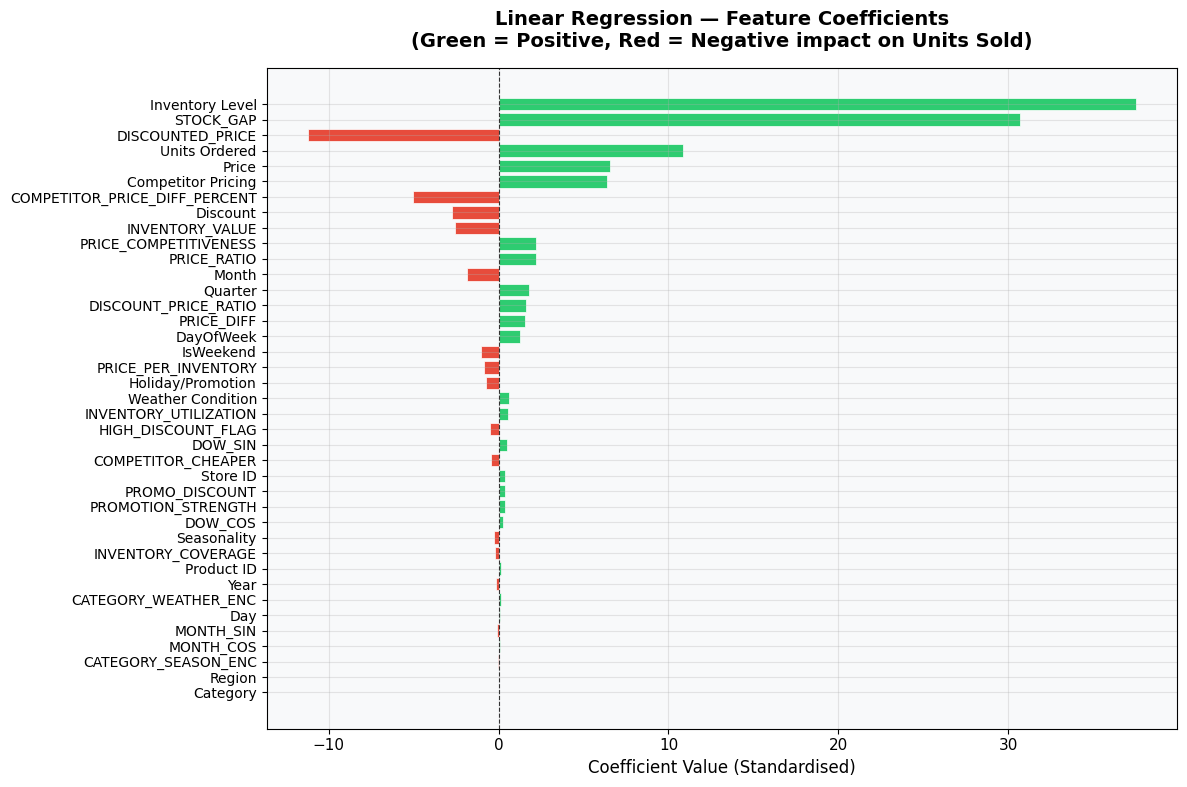

In [25]:
# --- Linear Regression: Feature Coefficients ---
coefs = pd.Series(lr_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs.values]
bars = ax.barh(range(len(coefs)), coefs.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index, fontsize=10)
ax.set_xlabel('Coefficient Value (Standardised)', fontsize=12)
ax.set_title('Linear Regression — Feature Coefficients\n(Green = Positive, Red = Negative impact on Units Sold)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='#333', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Model 2 — Random Forest Regressor

**Random Forest** builds an ensemble of decision trees, each trained on a bootstrap sample with random feature subsets. The final prediction is the average of all trees.

**Strengths:** Handles non-linearity, robust to outliers, provides feature importance.  
**Weaknesses:** Slower to train, can overfit with too many trees or too much depth.

In [26]:
rf_model = evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest',
    X_train, X_test, y_train, y_test  # Tree-based models don't need scaling
)


════════════════════════════════════════════════════════════
  📊 Random Forest
════════════════════════════════════════════════════════════

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               25.7168      69.5097      43.7929
  RMSE              33.3809      89.1873      55.8063
  R²                 0.9061       0.3282       0.5780



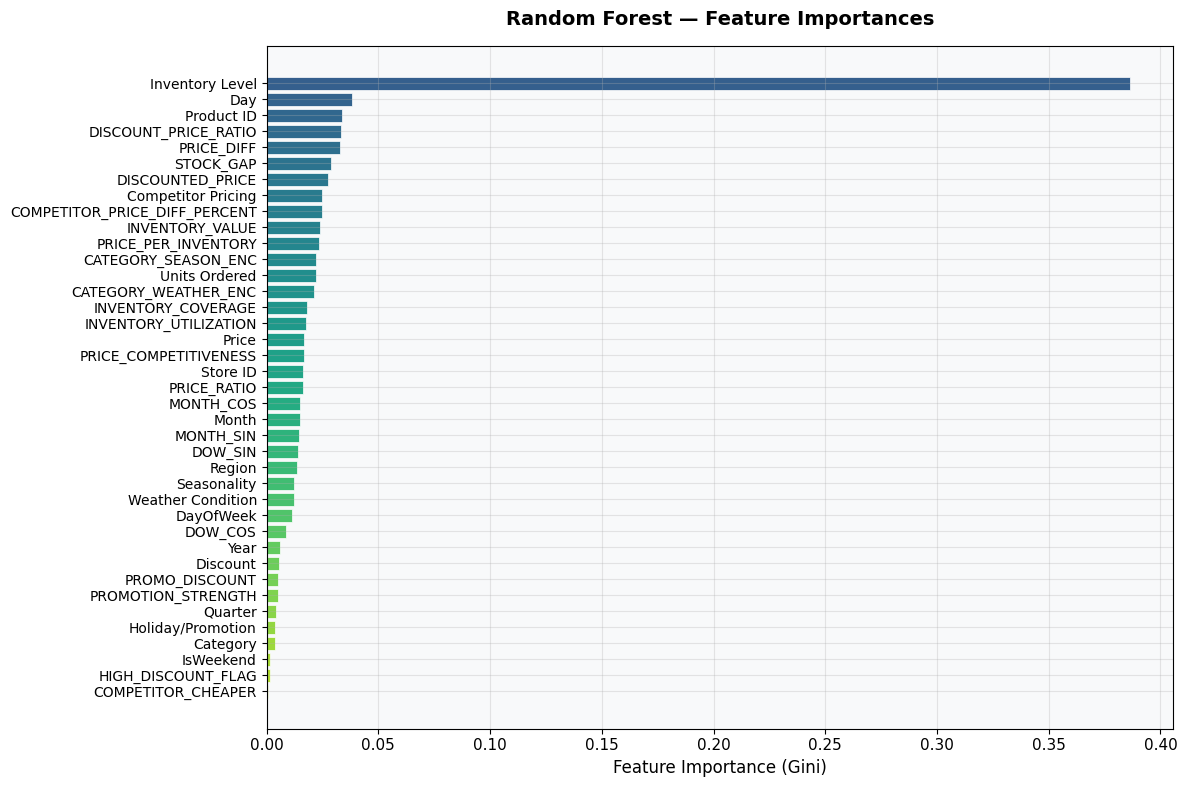

In [27]:
# --- Random Forest: Feature Importances ---
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_rf = plt.cm.viridis(np.linspace(0.3, 0.9, len(rf_importances)))
ax.barh(range(len(rf_importances)), rf_importances.values, color=colors_rf, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(rf_importances)))
ax.set_yticklabels(rf_importances.index, fontsize=10)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest — Feature Importances', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Model 3 — XGBoost Regressor

**XGBoost** (eXtreme Gradient Boosting) builds trees sequentially, where each new tree corrects the errors of the previous ensemble. It's often the top performer on structured/tabular data.

**Strengths:** State-of-the-art tabular performance, built-in regularisation, handles missing values.  
**Weaknesses:** More hyperparameters to tune, risk of overfitting without regularisation.

In [28]:
xgb_model = evaluate_model(
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'XGBoost',
    X_train, X_test, y_train, y_test  # Tree-based models don't need scaling
)


════════════════════════════════════════════════════════════
  📊 XGBoost
════════════════════════════════════════════════════════════

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               64.6446      69.1711       4.5264
  RMSE              82.1181      88.5637       6.4455
  R²                 0.4318       0.3375       0.0943



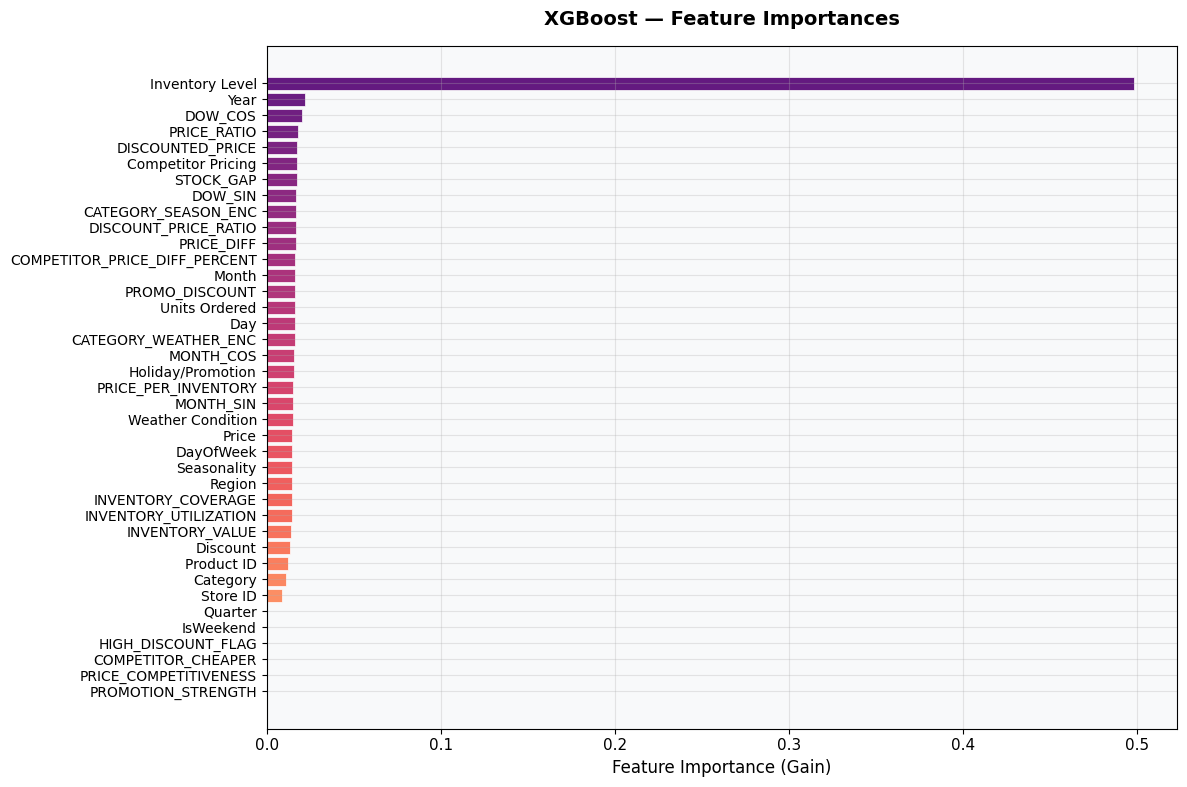

In [29]:
# --- XGBoost: Feature Importances ---
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_xgb = plt.cm.magma(np.linspace(0.3, 0.85, len(xgb_importances)))
ax.barh(range(len(xgb_importances)), xgb_importances.values, color=colors_xgb, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(xgb_importances)))
ax.set_yticklabels(xgb_importances.index, fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('XGBoost — Feature Importances', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. 📊 Comparative Results & Visualisation

Side-by-side comparison of all three baseline models across all evaluation metrics.

In [30]:
# --- 9a. Results Table ---
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print('╔' + '═'*72 + '╗')
print('║' + ' 📊  BASELINE MODEL COMPARISON — TEST SET RESULTS'.center(72) + '║')
print('╚' + '═'*72 + '╝')
print()

# Display only test metrics for clean comparison
comparison_df = results_df[['MAE (Test)', 'RMSE (Test)', 'R² (Test)']].copy()
comparison_df.columns = ['MAE', 'RMSE', 'R²']
comparison_df = comparison_df.round(4)
print(comparison_df.to_string())

# Highlight the best model
best_r2_model = comparison_df['R²'].idxmax()
best_mae_model = comparison_df['MAE'].idxmin()
best_rmse_model = comparison_df['RMSE'].idxmin()

print(f'\n🏆 Best MAE:  {best_mae_model} ({comparison_df.loc[best_mae_model, "MAE"]:.4f})')
print(f'🏆 Best RMSE: {best_rmse_model} ({comparison_df.loc[best_rmse_model, "RMSE"]:.4f})')
print(f'🏆 Best R²:   {best_r2_model} ({comparison_df.loc[best_r2_model, "R²"]:.4f})')

╔════════════════════════════════════════════════════════════════════════╗
║             📊  BASELINE MODEL COMPARISON — TEST SET RESULTS            ║
╚════════════════════════════════════════════════════════════════════════╝

                       MAE     RMSE      R²
Model                                      
Linear Regression  68.9306  88.0418  0.3453
Random Forest      69.5097  89.1873  0.3282
XGBoost            69.1711  88.5637  0.3375

🏆 Best MAE:  Linear Regression (68.9306)
🏆 Best RMSE: Linear Regression (88.0418)
🏆 Best R²:   Linear Regression (0.3453)


In [31]:
# --- 9b. Full Train vs Test Comparison ---
print('\n=== Full Train vs Test Performance ===\n')
print(results_df.round(4).to_string())


=== Full Train vs Test Performance ===

                   MAE (Train)  MAE (Test)  RMSE (Train)  RMSE (Test)  R² (Train)  R² (Test)
Model                                                                                       
Linear Regression      68.8309     68.9306       87.9038      88.0418      0.3490     0.3453
Random Forest          25.7168     69.5097       33.3809      89.1873      0.9061     0.3282
XGBoost                64.6446     69.1711       82.1181      88.5637      0.4318     0.3375


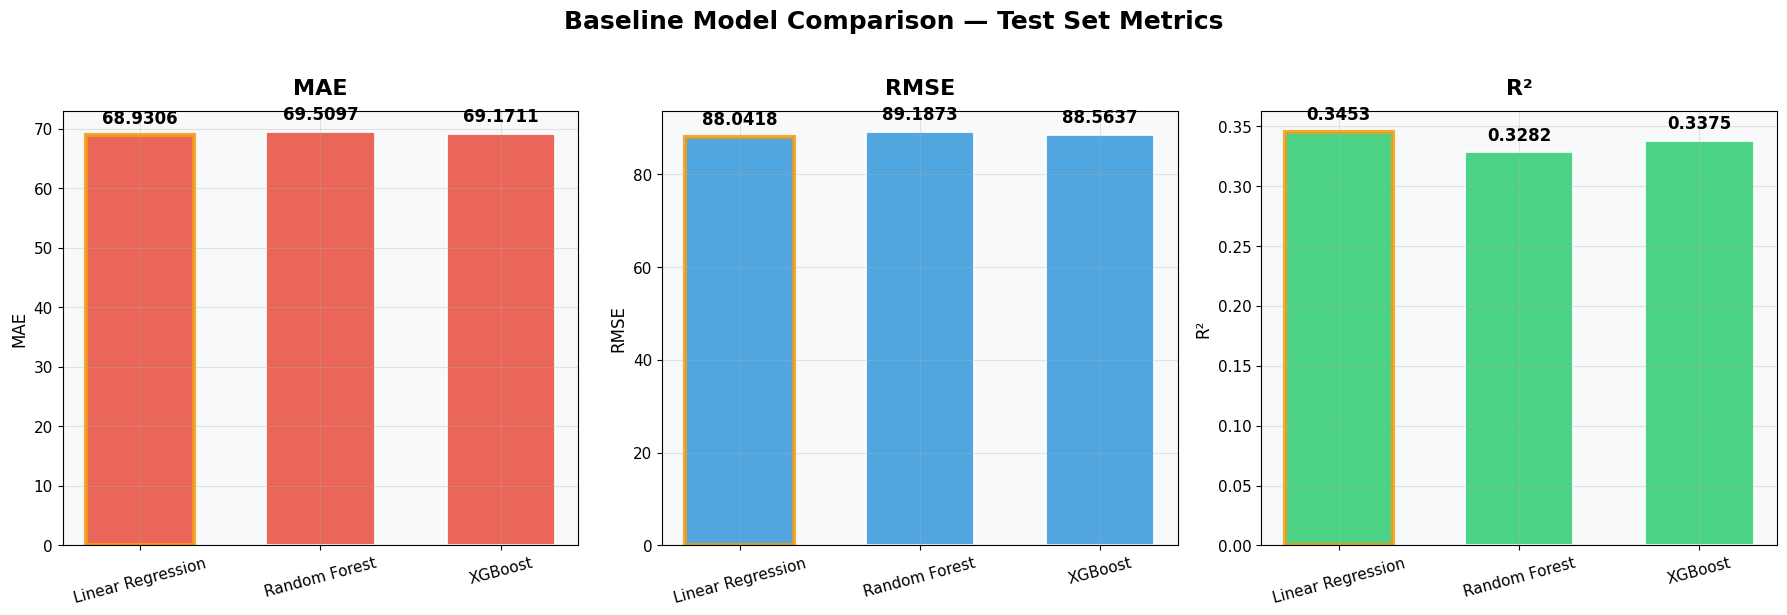

In [32]:
# --- 9c. Visual Comparison: Bar Charts ---
model_names = list(comparison_df.index)
metrics = ['MAE', 'RMSE', 'R²']
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax = axes[idx]
    values = comparison_df[metric].values
    bars = ax.bar(model_names, values, color=color, edgecolor='white',
                  linewidth=1.5, width=0.6, alpha=0.85)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_title(metric, fontsize=16, fontweight='bold', pad=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=15)
    
    # Highlight best
    if metric == 'R²':
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)
    bars[best_idx].set_edgecolor('#f39c12')
    bars[best_idx].set_linewidth(3)

fig.suptitle('Baseline Model Comparison — Test Set Metrics',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

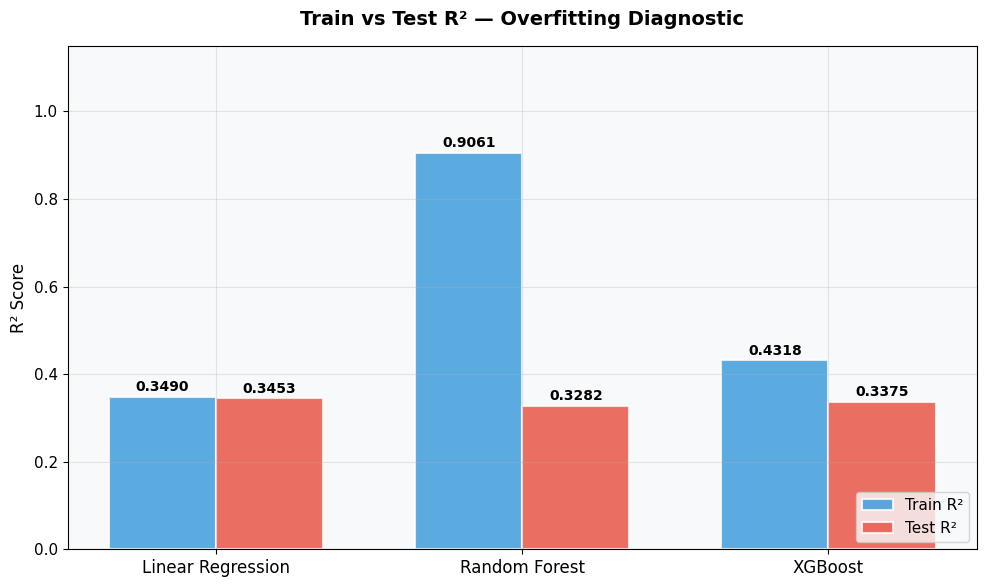

In [33]:
# --- 9d. Train vs Test R² (Overfitting Diagnostic) ---
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(model_names))
width = 0.35

r2_train_vals = [results[m]['R² (Train)'] for m in model_names]
r2_test_vals  = [results[m]['R² (Test)'] for m in model_names]

bars1 = ax.bar(x_pos - width/2, r2_train_vals, width, label='Train R²',
               color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, r2_test_vals, width, label='Test R²',
               color='#e74c3c', alpha=0.8, edgecolor='white', linewidth=1.5)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Train vs Test R² — Overfitting Diagnostic',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

---
## 10. Residual Analysis

Residuals (Actual − Predicted) reveal systematic biases. A good model should have residuals:
- Centred around zero (no systematic bias)
- Uniformly scattered (homoscedasticity)
- No visible patterns

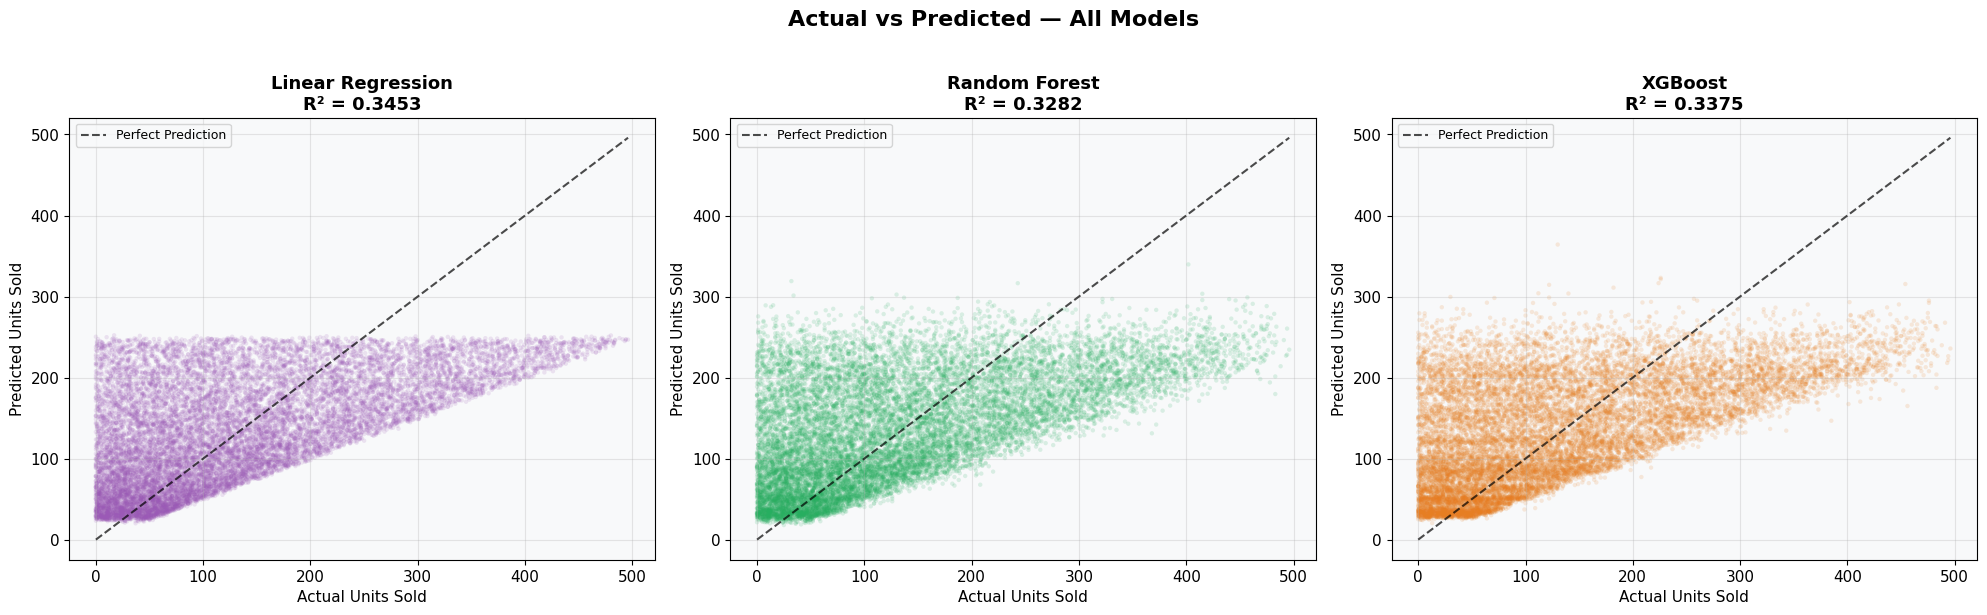

In [34]:
# --- 10a. Actual vs Predicted Scatter ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
scatter_colors = ['#9b59b6', '#27ae60', '#e67e22']

for idx, (model_name, color) in enumerate(zip(model_names, scatter_colors)):
    ax = axes[idx]
    y_pred = predictions[model_name]
    
    ax.scatter(y_test, y_pred, alpha=0.15, s=10, color=color, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, alpha=0.7, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Units Sold', fontsize=11)
    ax.set_ylabel('Predicted Units Sold', fontsize=11)
    ax.set_title(f'{model_name}\nR² = {results[model_name]["R² (Test)"]:.4f}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Actual vs Predicted — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

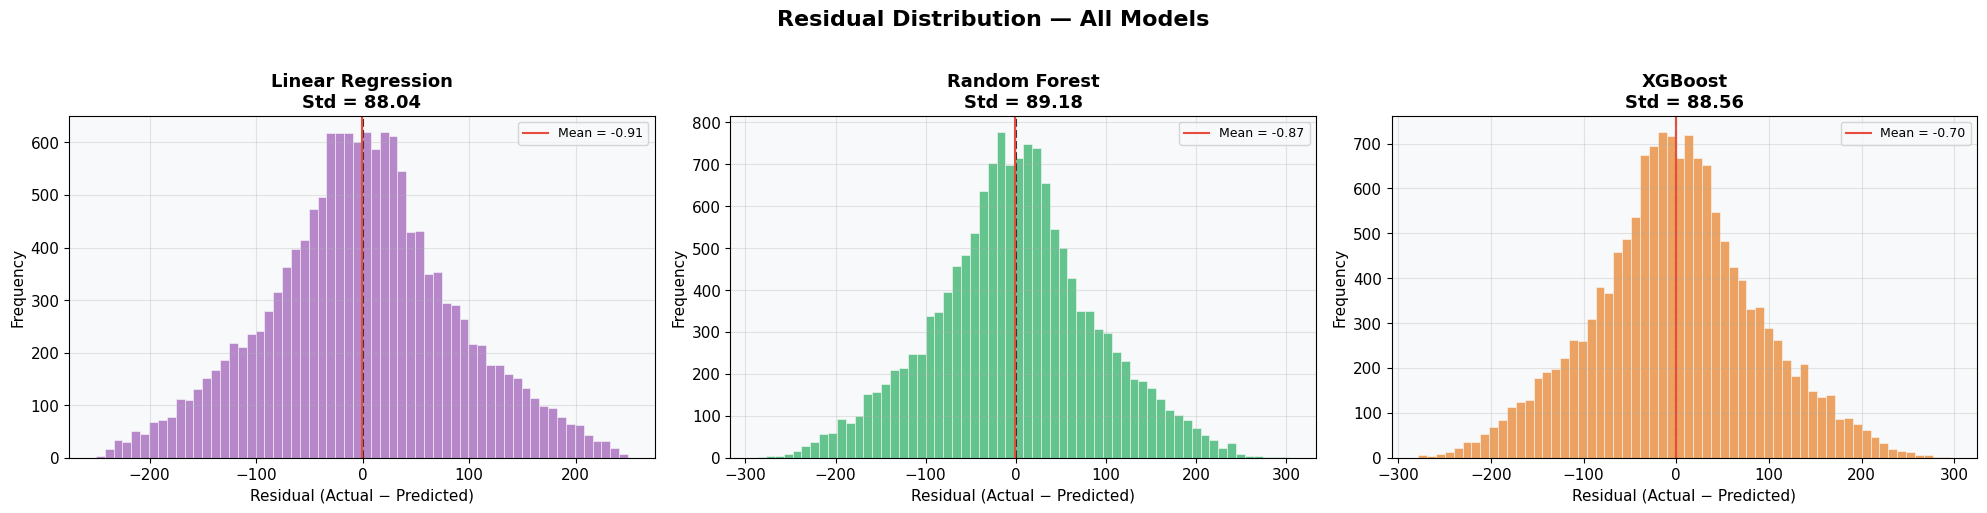

In [35]:
# --- 10b. Residual Distribution ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
hist_colors = ['#9b59b6', '#27ae60', '#e67e22']

for idx, (model_name, color) in enumerate(zip(model_names, hist_colors)):
    ax = axes[idx]
    residuals = y_test.values - predictions[model_name]
    
    ax.hist(residuals, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(x=0, color='#333', linewidth=1.5, linestyle='--')
    ax.axvline(x=np.mean(residuals), color='#e74c3c', linewidth=1.5, linestyle='-',
               label=f'Mean = {np.mean(residuals):.2f}')
    
    ax.set_xlabel('Residual (Actual − Predicted)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{model_name}\nStd = {np.std(residuals):.2f}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Residual Distribution — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 11. 📋 Conclusions & Next Steps

### Summary Table

In [36]:
# --- Final Summary ---
print('╔' + '═'*72 + '╗')
print('║' + ' 📋  BASELINE MODELS — FINAL SUMMARY'.center(72) + '║')
print('╚' + '═'*72 + '╝')
print()
print(comparison_df.to_string())
print()
print('─' * 72)

# Determine overall best model
overall_best = comparison_df['R²'].idxmax()
print(f'\n🏆 Overall Best Baseline Model: {overall_best}')
print(f'   R² = {comparison_df.loc[overall_best, "R²"]:.4f}  |  '
      f'MAE = {comparison_df.loc[overall_best, "MAE"]:.4f}  |  '
      f'RMSE = {comparison_df.loc[overall_best, "RMSE"]:.4f}')

# Overfitting assessment
print('\n─── Overfitting Assessment ───')
for model_name in model_names:
    gap = results[model_name]['R² (Train)'] - results[model_name]['R² (Test)']
    status = '✅ Minimal' if gap < 0.05 else ('⚠️ Moderate' if gap < 0.15 else '❌ Severe')
    print(f'  {model_name:<22} Train-Test R² Gap: {gap:.4f}  →  {status}')

╔════════════════════════════════════════════════════════════════════════╗
║                   📋  BASELINE MODELS — FINAL SUMMARY                   ║
╚════════════════════════════════════════════════════════════════════════╝

                       MAE     RMSE      R²
Model                                      
Linear Regression  68.9306  88.0418  0.3453
Random Forest      69.5097  89.1873  0.3282
XGBoost            69.1711  88.5637  0.3375

────────────────────────────────────────────────────────────────────────

🏆 Overall Best Baseline Model: Linear Regression
   R² = 0.3453  |  MAE = 68.9306  |  RMSE = 88.0418

─── Overfitting Assessment ───
  Linear Regression      Train-Test R² Gap: 0.0037  →  ✅ Minimal
  Random Forest          Train-Test R² Gap: 0.5780  →  ❌ Severe
  XGBoost                Train-Test R² Gap: 0.0943  →  ⚠️ Moderate


### Key Takeaways

1. **Linear Regression** provides the simplest baseline — if non-linear models significantly outperform it, the data has important non-linear patterns.
2. **Random Forest** is expected to outperform Linear Regression due to its ability to capture feature interactions and non-linearities, but watch for overfitting (large train–test gap).
3. **XGBoost** typically achieves the best performance on tabular data thanks to sequential boosting and built-in regularisation.

### Next Steps
- **Hyperparameter Tuning:** Use `GridSearchCV` or `Optuna` to optimise the best-performing model.
- **Cross-Validation:** Replace the single train–test split with k-fold CV for more robust estimates.
- **Advanced Models:** Try LightGBM, CatBoost, or stacking ensembles.
- **Feature Selection:** Drop low-importance features to reduce noise and improve generalisation.